# SDSS Galaxies vs quasars

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
from astroML.utils import split_samples
from sklearn import metrics 
from sklearn.metrics import roc_curve

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier

Data are SDSS measurements in different bands and class GALAXY or QSO (which I'll write respectively as 0 or 1)

In [3]:
data = pd.read_csv("galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [4]:
le = LabelEncoder()

# Assign 1 or 0 to quasar or galaxy
data['class'] = le.fit_transform(data['class'])
labels = le.inverse_transform(data['class'])
class_names = le.classes_
print(class_names)

['GALAXY' 'QSO']


In [5]:
qso_gal=data['class'].to_numpy()
qso_gal

array([1, 0, 0, ..., 0, 0, 0])

In [6]:
colors=pd.read_csv("galaxyquasar.csv", usecols=["u","g","r","i","z"])
colors=colors.to_numpy()

In [7]:
colors

array([[18.97213, 18.53676, 18.5828 , 18.34936, 18.29215],
       [19.24592, 17.47646, 16.47817, 16.04472, 15.68851],
       [19.43536, 17.70268, 16.91565, 16.58327, 16.39128],
       ...,
       [18.62718, 17.30876, 16.87371, 16.62399, 16.42296],
       [19.5514 , 18.27711, 17.62101, 17.21947, 17.03347],
       [18.80772, 17.75751, 17.405  , 17.2165 , 17.12295]])

In [8]:
colors[:,0]

array([18.97213, 19.24592, 19.43536, ..., 18.62718, 19.5514 , 18.80772])

I subtract colors (u-g),(g-r),(r-i),(i-z) and these will be the 4 features of each object. I will perform classification using these features

In [9]:
u_g=colors[:,0]-colors[:,1]
g_r=colors[:,1]-colors[:,2]
r_i=colors[:,2]-colors[:,3]
i_z=colors[:,3]-colors[:,4]

four features (full dataset)

In [10]:
X = np.column_stack((u_g, g_r, r_i, i_z))
X

array([[ 0.43537, -0.04604,  0.23344,  0.05721],
       [ 1.76946,  0.99829,  0.43345,  0.35621],
       [ 1.73268,  0.78703,  0.33238,  0.19199],
       ...,
       [ 1.31842,  0.43505,  0.24972,  0.20103],
       [ 1.27429,  0.6561 ,  0.40154,  0.186  ],
       [ 1.05021,  0.35251,  0.1885 ,  0.09355]])

In [11]:
X.shape

(50000, 4)

Quick visualization of the 4 features with an histogram (not using labels)

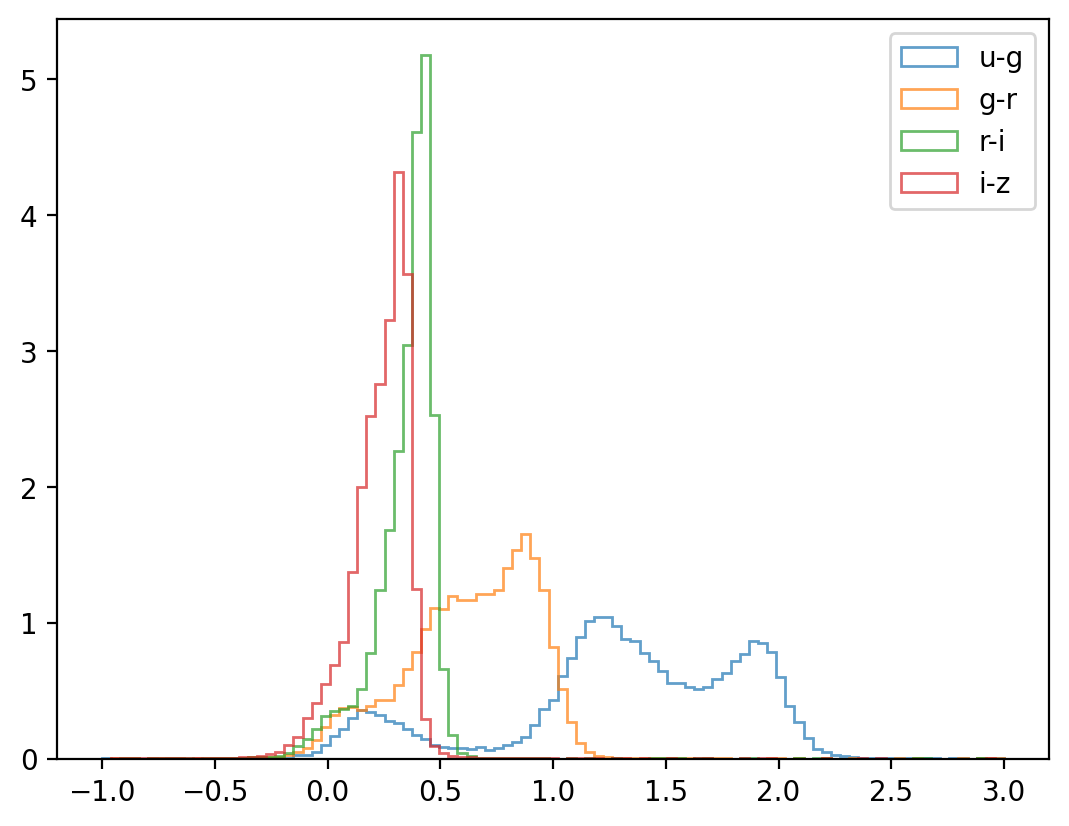

In [12]:
plt.hist(u_g,bins=np.linspace(-1,3,100), label='u-g', alpha=0.7, histtype='step', density=True)
plt.hist(g_r,bins=np.linspace(-1,3,100), label='g-r', alpha=0.7, histtype='step', density=True)
plt.hist(r_i,bins=np.linspace(-1,3,100), label='r-i', alpha=0.7, histtype='step', density=True)
plt.hist(i_z,bins=np.linspace(-1,3,100), label='i-z', alpha=0.7, histtype='step', density=True)
plt.legend()
plt.show();

u-g feature shows a bimodality

Quick visualization of each feature using labels to disinguish between GAL and QSO

u-g

Text(0.5, 0, 'u-g')

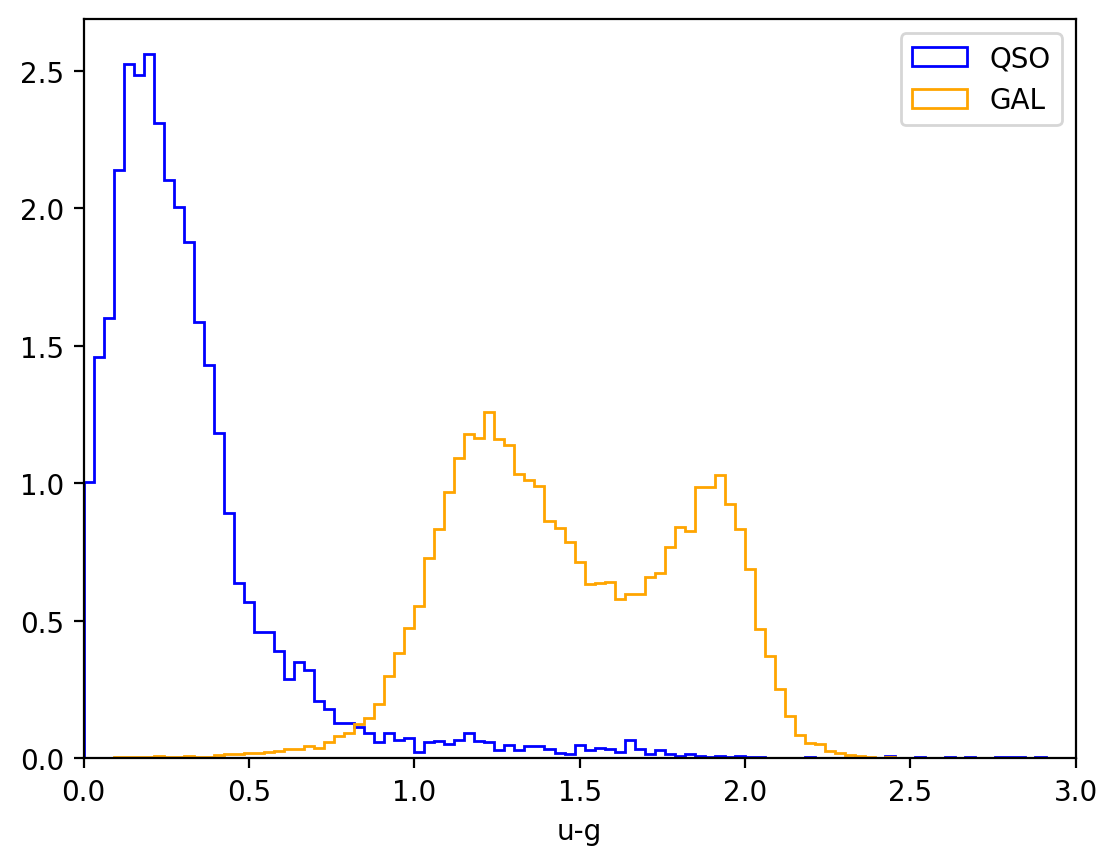

In [13]:
plt.hist(u_g[qso_gal==1],histtype='step',bins=np.linspace(0,3,100),density=True, color='blue',label='QSO')
plt.hist(u_g[qso_gal==0],histtype='step',bins=np.linspace(0,3,100),density=True, color='orange', label='GAL')
plt.xlim(0,3)
plt.legend()
plt.xlabel('u-g')

g-r

Text(0.5, 0, 'g-r')

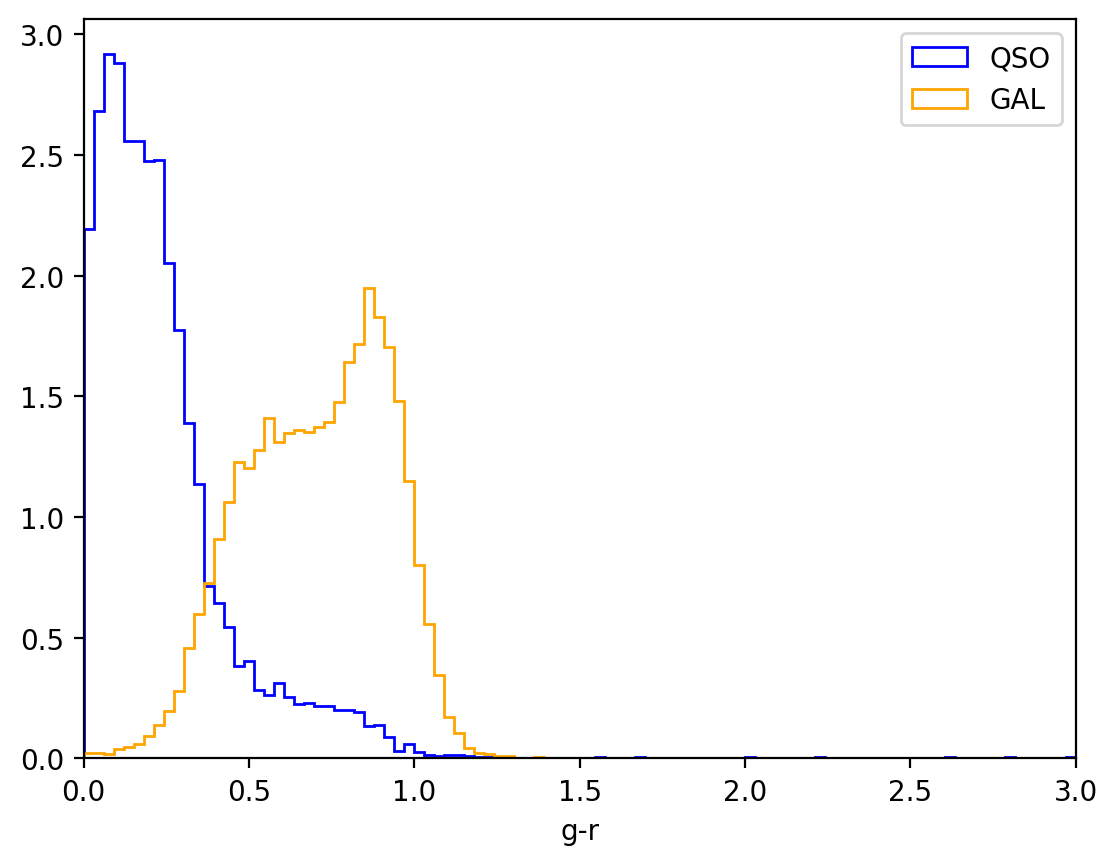

In [14]:
plt.hist(g_r[qso_gal==1],histtype='step',bins=np.linspace(0,3,100),density=True, color='blue',label='QSO')
plt.hist(g_r[qso_gal==0],histtype='step',bins=np.linspace(0,3,100),density=True, color='orange', label='GAL')
plt.xlim(0,3)
plt.legend()
plt.xlabel('g-r')

r-i

Text(0.5, 0, 'r-i')

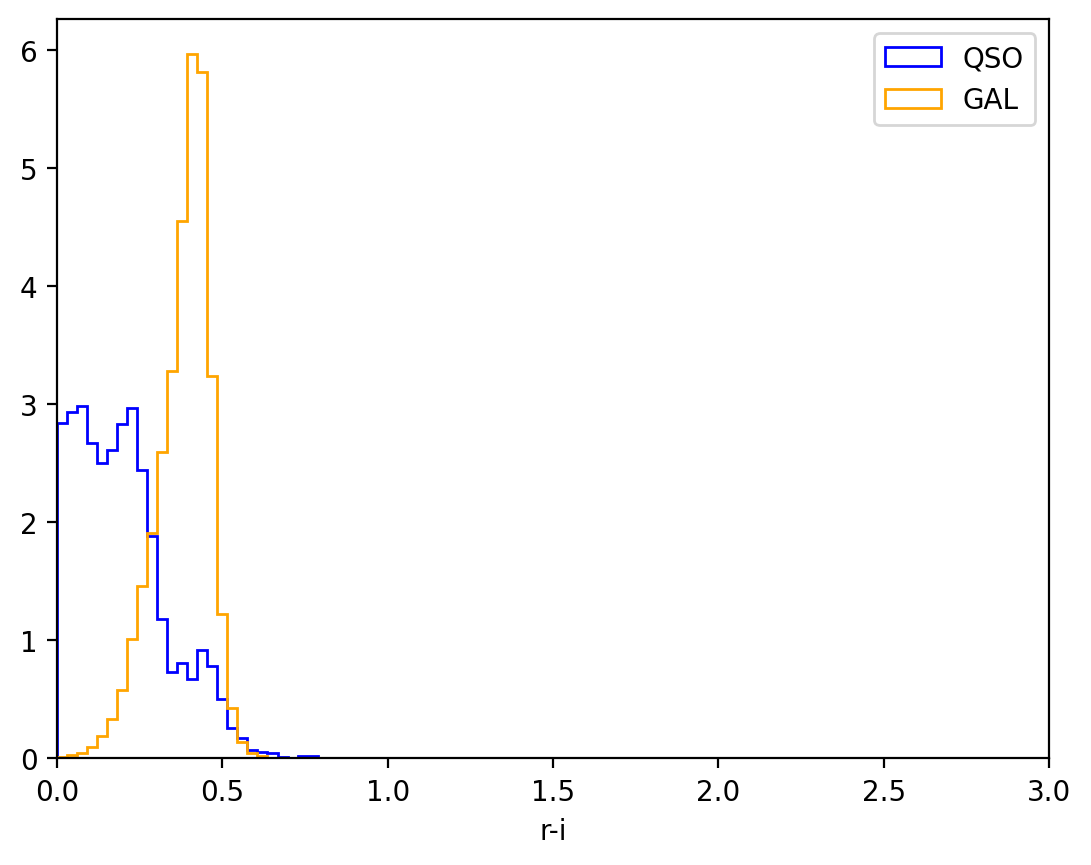

In [15]:
plt.hist(r_i[qso_gal==1],histtype='step',bins=np.linspace(0,3,100),density=True, color='blue',label='QSO')
plt.hist(r_i[qso_gal==0],histtype='step',bins=np.linspace(0,3,100),density=True, color='orange', label='GAL')
plt.xlim(0,3)
plt.legend()
plt.xlabel('r-i')

i-z

Text(0.5, 0, 'i-z')

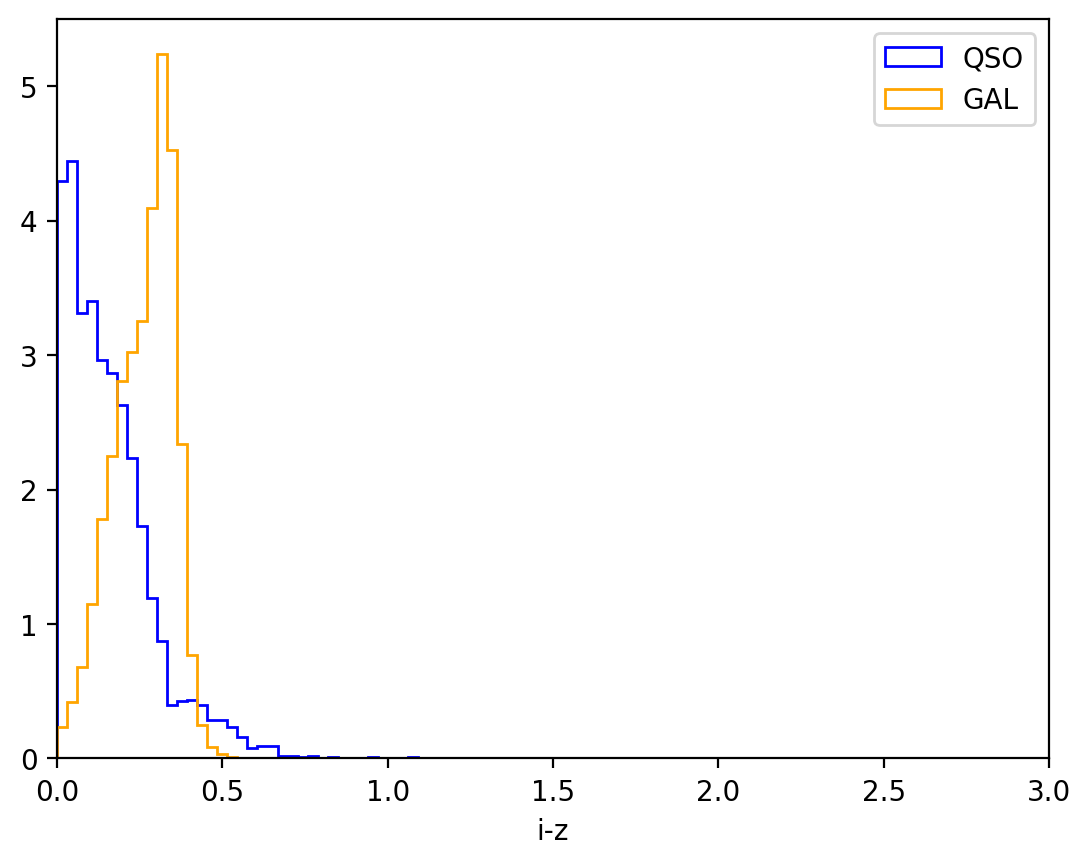

In [16]:
plt.hist(i_z[qso_gal==1],histtype='step',bins=np.linspace(0,3,100),density=True, color='blue',label='QSO')
plt.hist(i_z[qso_gal==0],histtype='step',bins=np.linspace(0,3,100),density=True, color='orange', label='GAL')
plt.xlim(0,3)
plt.legend()
plt.xlabel('i-z')

Quick corner plot visualization to see if different features are correlated

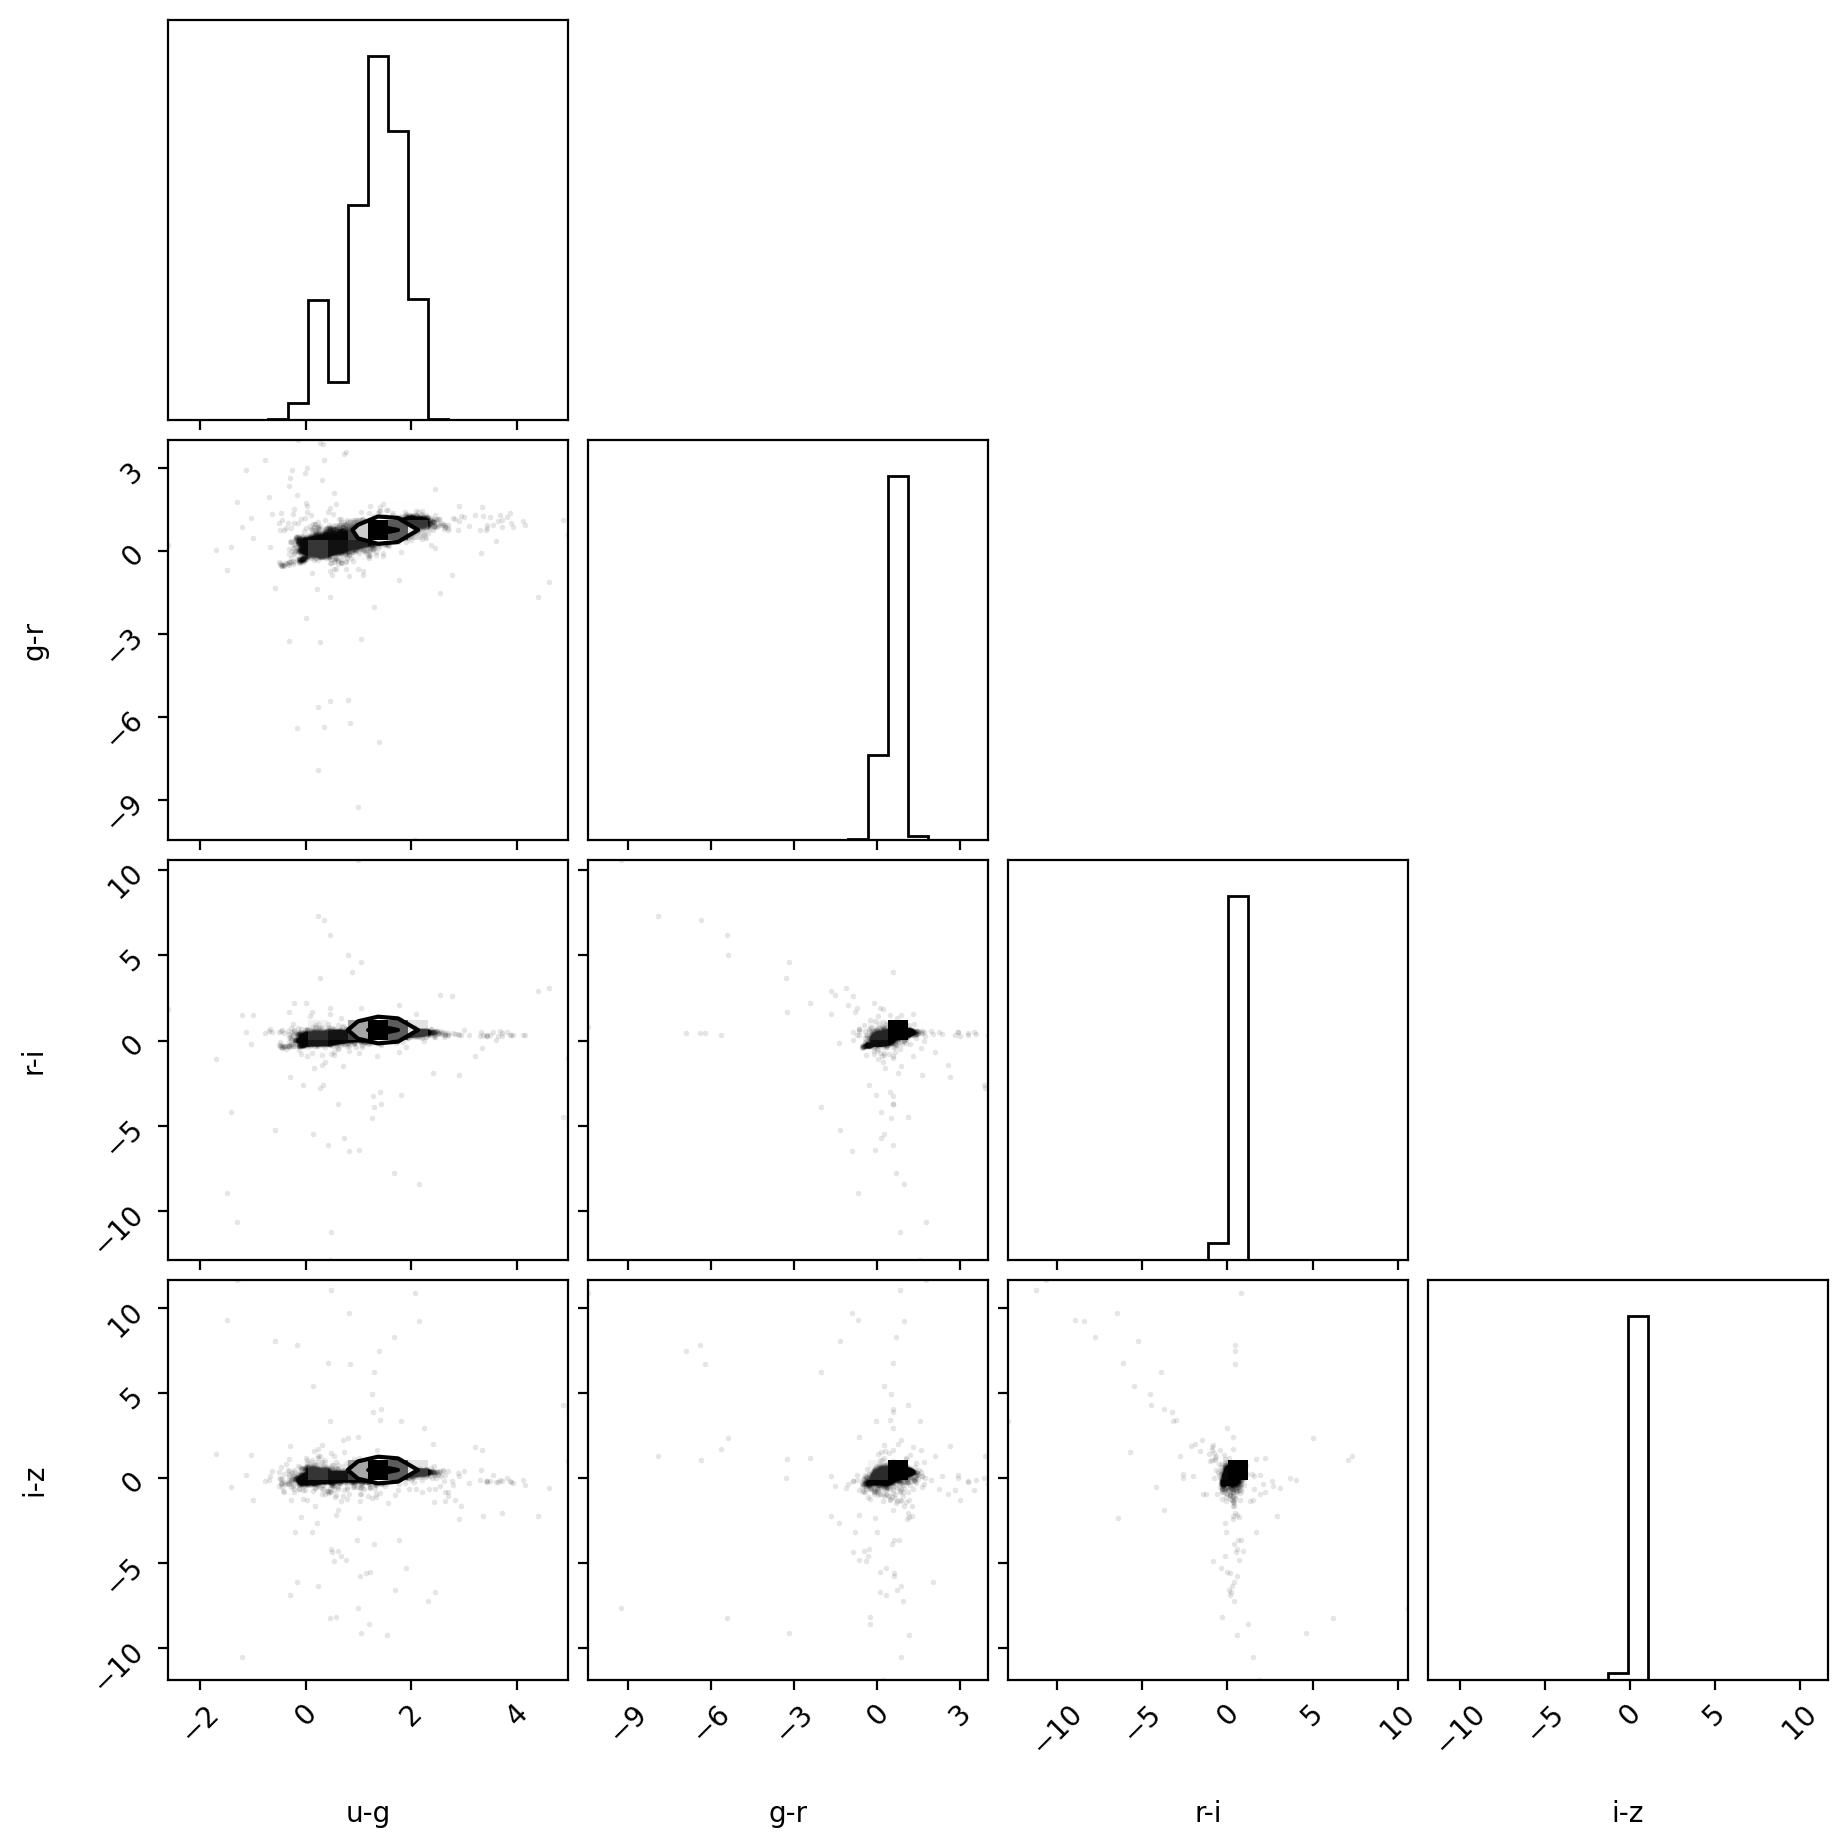

In [17]:
import corner
corner.corner(X, labels=['u-g', 'g-r', 'r-i', 'i-z']);

In [18]:
corr_matrix = pd.DataFrame(X, columns=['u-g','g-r','r-i','i-z']).corr()
corr_matrix

,u-g,g-r,r-i,i-z
u-g,1.000000,0.803315,0.469237,0.360335
g-r,0.803315,1.000000,0.347712,0.318454
r-i,0.469237,0.347712,1.000000,-0.158128
i-z,0.360335,0.318454,-0.158128,1.000000


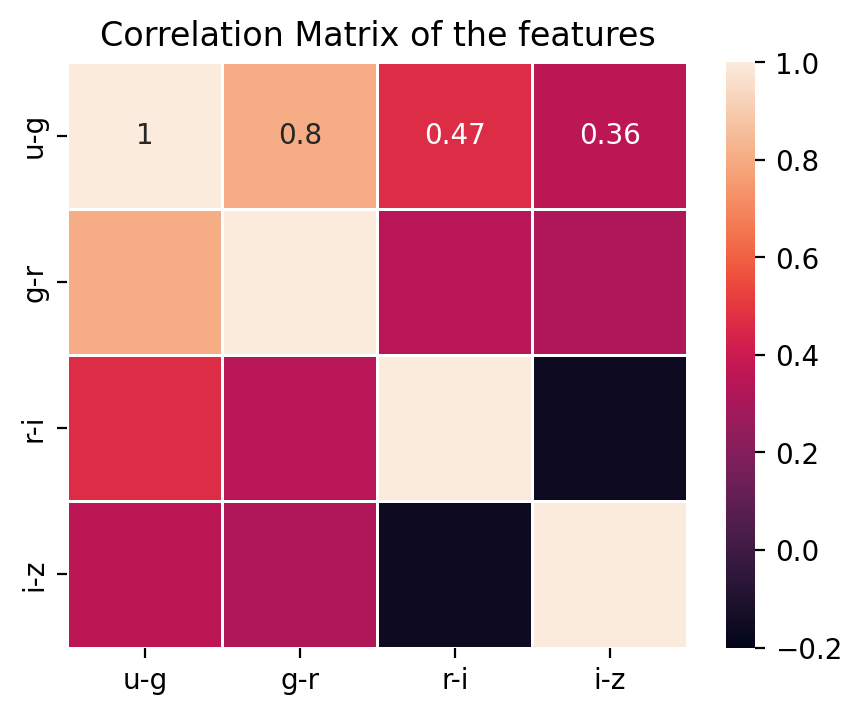

In [19]:
plt.subplots(figsize=(5,3.8))

sns.heatmap(corr_matrix, annot=True, vmin=-0.2, vmax=1.0, linewidth=0.5)
plt.title("Correlation Matrix of the features")
plt.show()

Quick histogram visualization (u-g feature) with and without labels

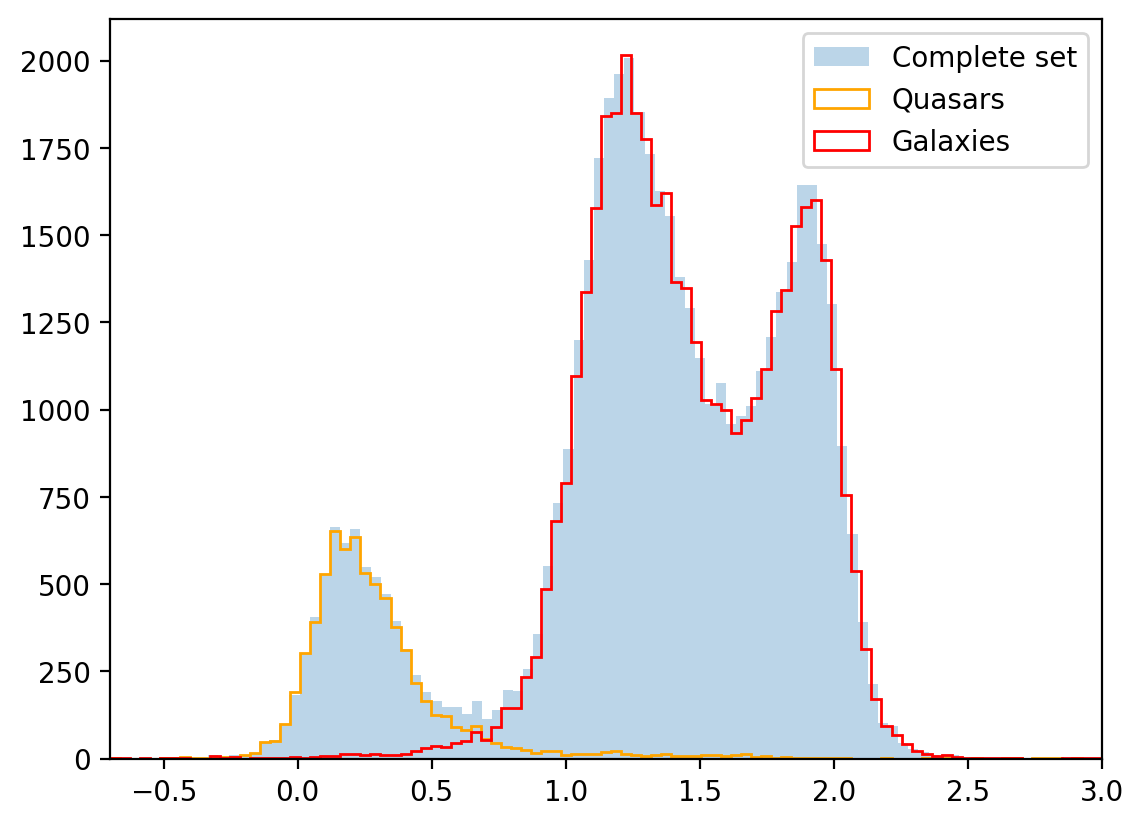

In [20]:
plt.hist(u_g, bins=200, label='Complete set', alpha=0.3)
plt.hist(u_g[qso_gal == 1], histtype='step', bins=np.linspace(-0.7, 3, 100), label='Quasars', color='orange')
plt.hist(u_g[qso_gal == 0], histtype='step', bins=np.linspace(-0.7, 3, 100), label='Galaxies', color='red')

plt.xlim(-0.7, 3)
plt.legend()
plt.show()

In [21]:
#train-test split
(X_train, X_test), (y_train, y_test) = split_samples(X, qso_gal, [0.75, 0.25], random_state=0)

In [22]:
X_train.shape

(37500, 4)

I perform classification using different algorithms (fit on the training set and predict on the test set): for each of them I use increasingly more features and visualize the ROC curve

# Naive-Bayes Gaussian

Gaussian Naive Bayes assumes that all features are independent

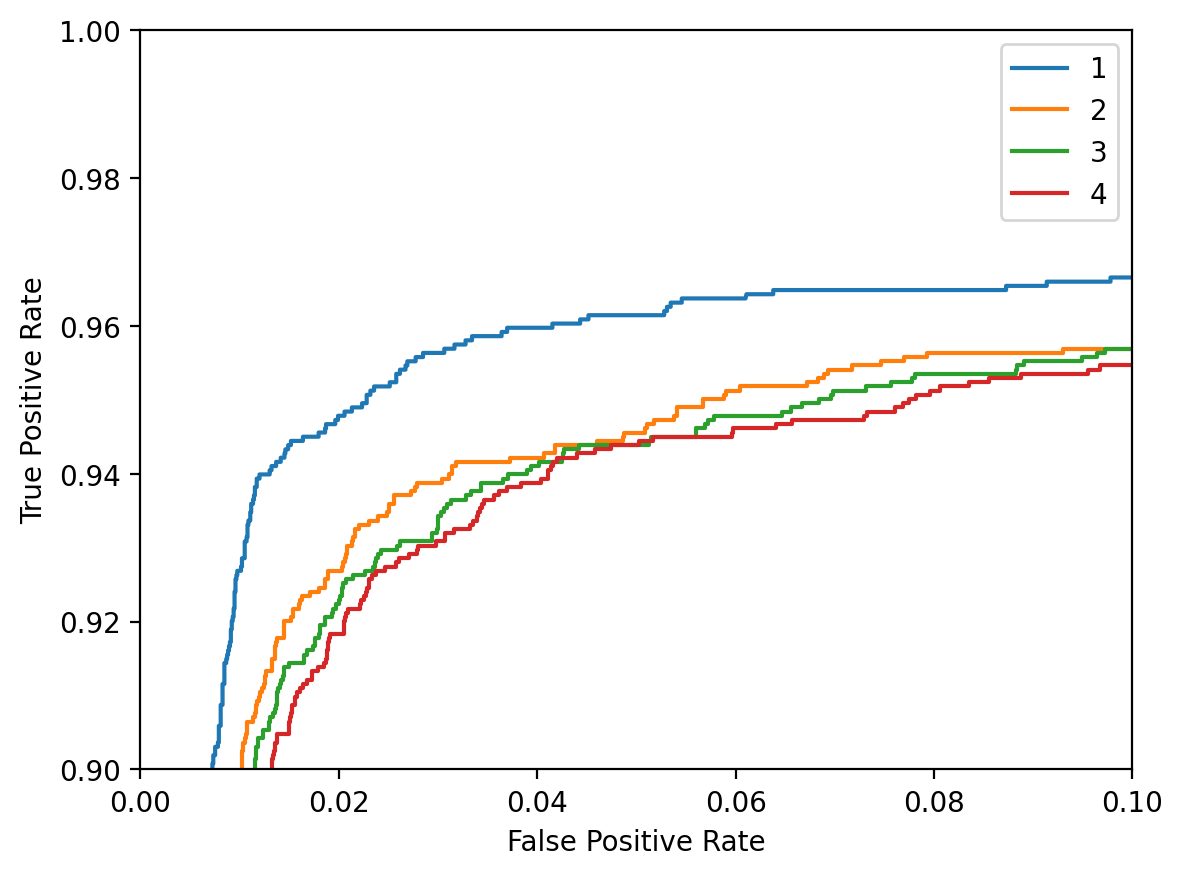

In [23]:
gnb = GaussianNB()

for i in range(4): #from 1 to 4 features

    gnb.fit(X_train[:,0:i+1],y_train )

    y_prob = gnb.predict_proba(X_test[:,0:i+1]) [:,1] 
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(i+1))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.legend();

When predicting on the test set, the algorithm classifies unseen data with 0 or 1: here we keep track of TP and FP obtained (when comparing predicted labels with given labels - y_test -). We are interested in having many TPs I guess... so using more than the first feature alone in this case doesn't improve the performace, since, given a fixed FPR, the blue curve shows the higher corresponding TPR.

# Quadratic discriminant

(0.0, 0.03)

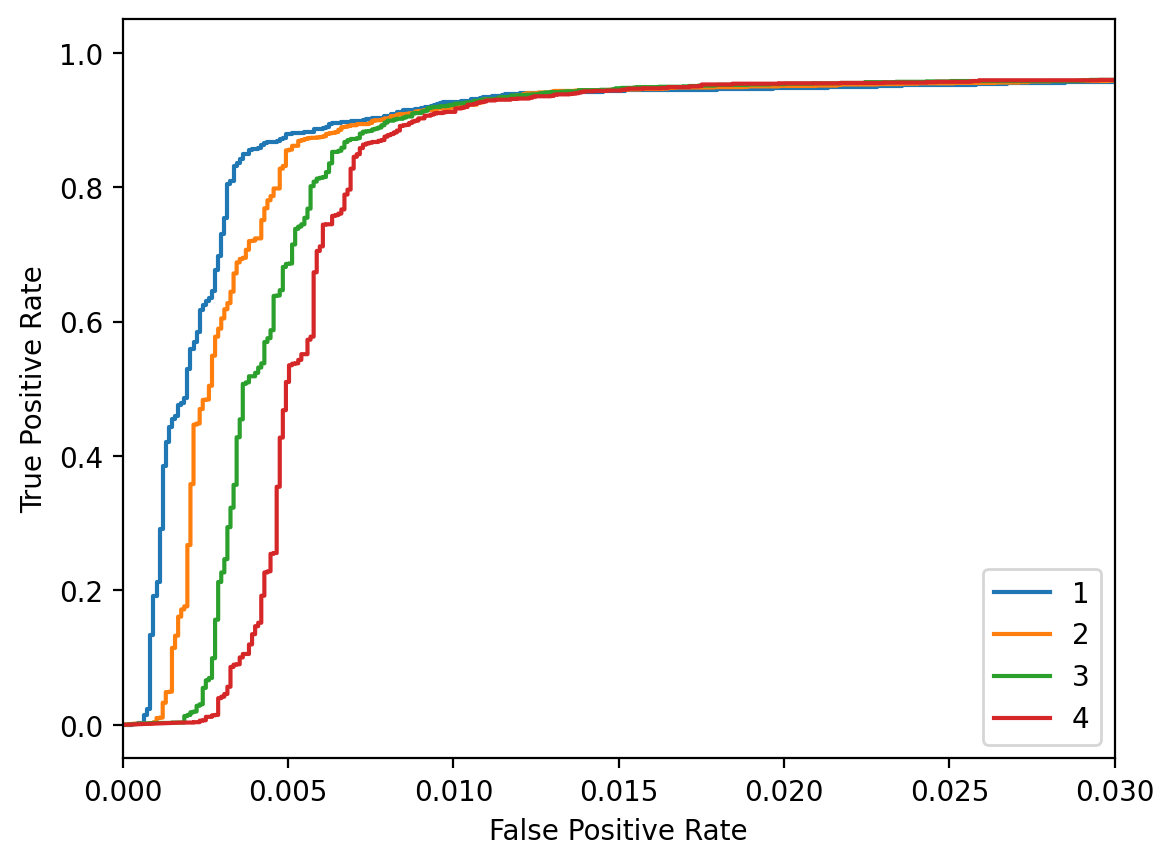

In [24]:
qda = QDA()

for i in range(4):

    qda.fit(X_train[:,0:i+1] ,y_train )

    y_prob = qda.predict_proba(X_test[:,0:i+1]) [:,1] 
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(i+1))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.xlim(0,0.03)

# GMMBayes

here I use 4 features together to train the algorithm and increasingly more components in my model (which estimates the density of the two generating processes, so the QSO and GAL pdfs)

(0.0, 0.03)

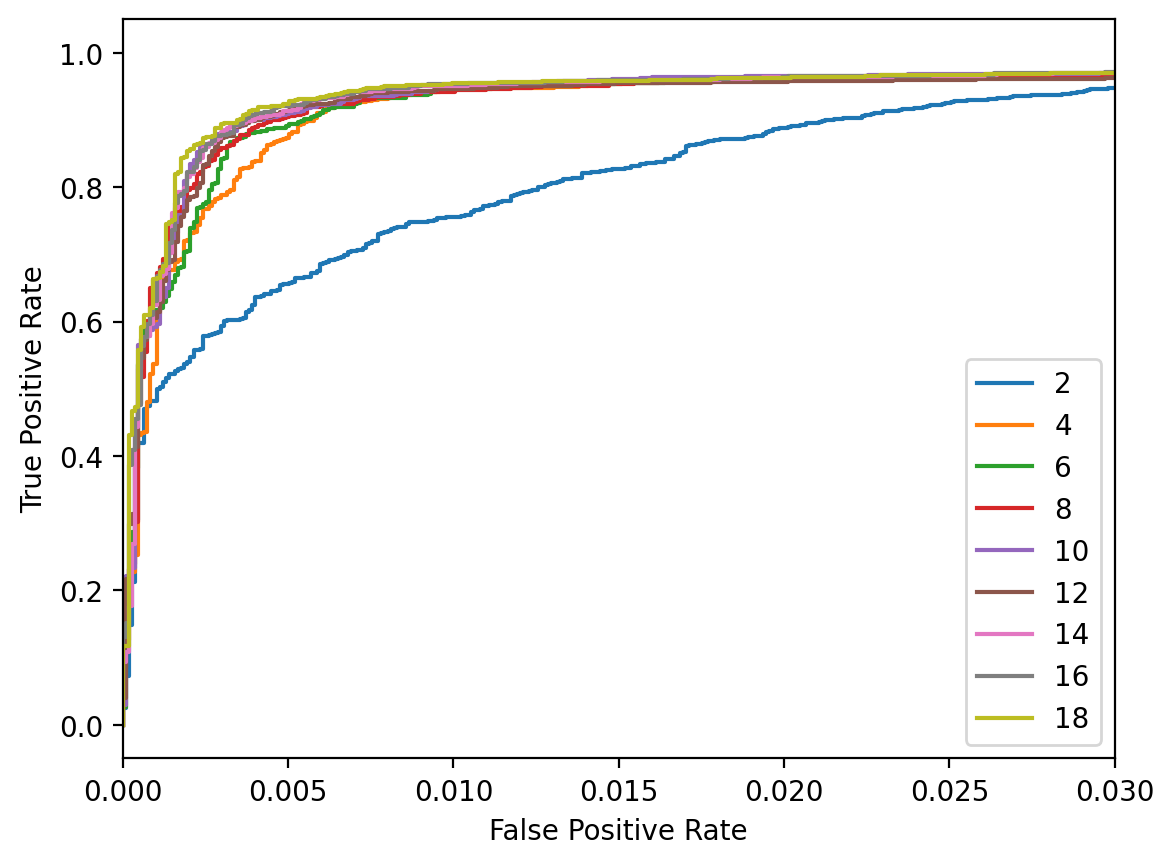

In [25]:
for n in np.arange(2,20)[::2]:
    
    clf = GMMBayes(n_components=n)
    clf.fit(X_train,y_train)
    
    y_prob = clf.predict_proba(X_test) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.xlim(0,0.03)

We can see that the algorihm has a better performance if the model has more components: given a fixed number of FPR, 18 components will score a higher TPR than 2 or 4 components

But we can also say that from 6 components (and on) the ROC curves are all very similar

# KNeighbors

here I use again 4 component together to train and increase the number of nearest neighbors considered (from 2 to 9)

(0.9, 1.0)

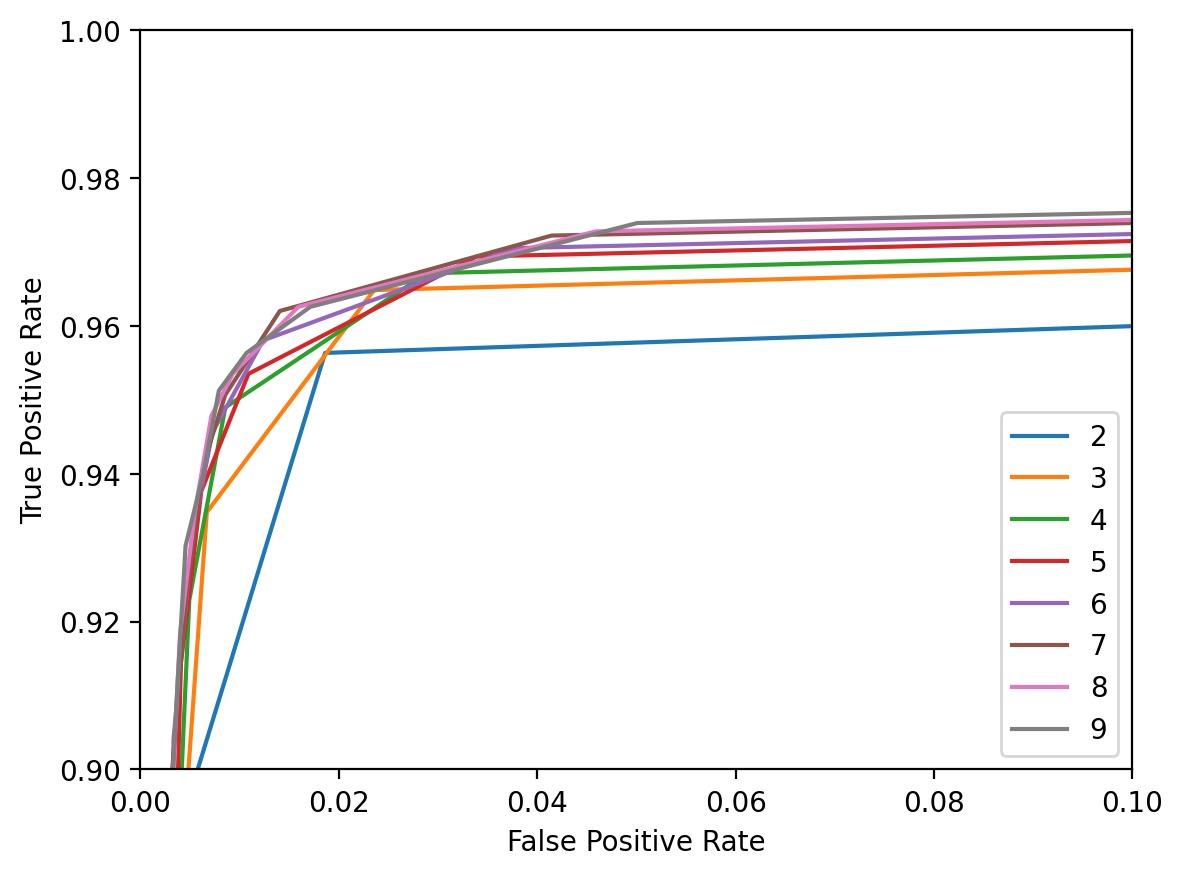

In [26]:
for n in np.arange(2,10):
    clf = KNeighborsClassifier(n_neighbors=n)
    clf.fit(X_train,y_train)
    
    y_prob = clf.predict_proba(X_test) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

Even in this case considering more neighbors results in a better classification, which is expected since KNeighbors assigns to the unseen data the same label as the one of the majority of the neighbors considered

Now I choose to use GMMBayes with 6 components (4 features) to perform classification

In [27]:
gmm = GMMBayes(n_components=6)

gmm.fit(X_train,y_train)

y_pred = gmm.predict(X_test)

I plot the histogram of the first feature with and without the given labels and the test set histogram with the predicted labels (green and blue)

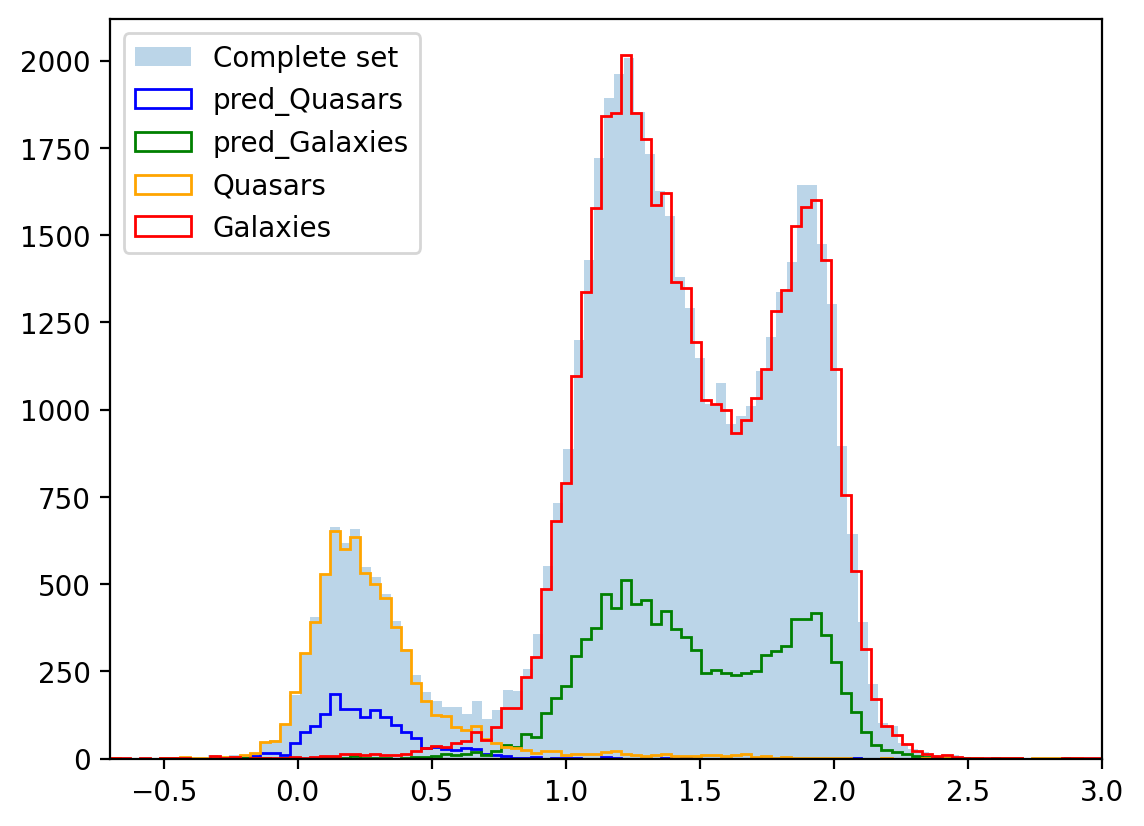

In [28]:
plt.hist(u_g, bins=200, label='Complete set', alpha=0.3)
plt.hist(X_test[:,0][y_pred == 1], histtype='step', bins=np.linspace(-0.7, 3, 100), label='pred_Quasars', color='blue')
plt.hist(X_test[:,0][y_pred == 0], histtype='step', bins=np.linspace(-0.7, 3, 100), label='pred_Galaxies', color='green')
plt.hist(u_g[qso_gal == 1], histtype='step', bins=np.linspace(-0.7, 3, 100), label='Quasars', color='orange')
plt.hist(u_g[qso_gal == 0], histtype='step', bins=np.linspace(-0.7, 3, 100), label='Galaxies', color='red')

plt.xlim(-0.7, 3)
plt.legend()
plt.show()

The bimodality is recovered

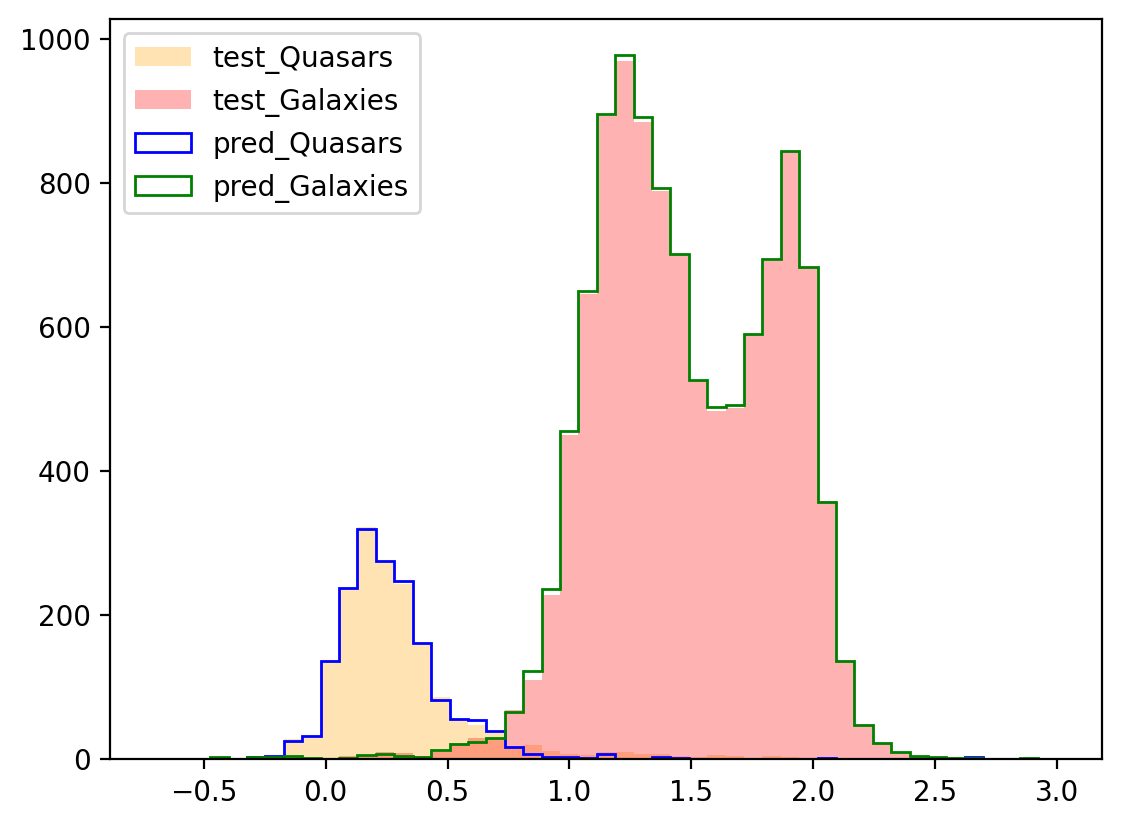

In [29]:
plt.hist(X_test[:,0][y_test == 1], alpha=0.3, bins=np.linspace(-0.7, 3, 50), label='test_Quasars', color='orange')
plt.hist(X_test[:,0][y_test == 0], alpha=0.3, bins=np.linspace(-0.7, 3, 50), label='test_Galaxies', color='red')
plt.hist(X_test[:,0][y_pred == 1], histtype='step', bins=np.linspace(-0.7, 3, 50), label='pred_Quasars', color='blue')
plt.hist(X_test[:,0][y_pred == 0], histtype='step', bins=np.linspace(-0.7, 3, 50), label='pred_Galaxies', color='green')
plt.legend()
plt.show();

In [30]:
import sklearn
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(C)

Confusion matrix:
[[10662    74]
 [  133  1631]]


In [31]:
from sklearn.metrics import accuracy_score
accuracy_dt = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy_dt)

Accuracy: 0.98344
